In [1]:
import pandas as pd
import os

# ── Paths ──────────────────────────────────────────────
RAW = '../data/raw/'
PROCESSED = '../data/processed/'
os.makedirs(PROCESSED, exist_ok=True)

# ══════════════════════════════════════════════════════
# STEP 1 — Load IPL Data
# ══════════════════════════════════════════════════════
ipl = pd.read_csv(RAW + 'matches.csv')
print("IPL shape:", ipl.shape)
print(ipl[['date', 'city', 'match_type']].head())

IPL shape: (1095, 20)
         date        city match_type
0  2008-04-18   Bangalore     League
1  2008-04-19  Chandigarh     League
2  2008-04-19       Delhi     League
3  2008-04-20      Mumbai     League
4  2008-04-20     Kolkata     League


In [2]:
# ══════════════════════════════════════════════════════
# STEP 2 — Clean IPL Data
# ══════════════════════════════════════════════════════

# Convert date to datetime
ipl['date'] = pd.to_datetime(ipl['date'])

# Keep only columns we need
ipl_clean = ipl[['date', 'city', 'match_type', 'season']].copy()

# Add event type
ipl_clean['event_type'] = 'IPL'

# Add importance — finals and qualifiers spike harder than league matches
ipl_clean['importance'] = ipl_clean['match_type'].apply(
    lambda x: 'Very High' if x == 'Final' 
    else 'High' if x in ['Qualifier', 'Eliminator', 'Semi Final'] 
    else 'Medium'
)

# Map city to region
region_map = {
    'Mumbai': 'West', 'Pune': 'West', 'Ahmedabad': 'West', 'Rajkot': 'West', 'Nagpur': 'West',
    'Delhi': 'North', 'Chandigarh': 'North', 'Jaipur': 'North', 'Dharamsala': 'North', 'Cuttack': 'North',
    'Kolkata': 'East', 'Guwahati': 'East',
    'Chennai': 'South', 'Bangalore': 'South', 'Hyderabad': 'South', 'Visakhapatnam': 'South',
    'Kochi': 'South', 'Indore': 'West'
}

ipl_clean['region'] = ipl_clean['city'].map(region_map)

# Check how many cities didn't get mapped
print("Unmapped cities:")
print(ipl_clean[ipl_clean['region'].isna()]['city'].unique())

print("\nIPL clean shape:", ipl_clean.shape)
print(ipl_clean.head())

Unmapped cities:
['Cape Town' 'Port Elizabeth' 'Durban' 'Centurion' 'East London'
 'Johannesburg' 'Kimberley' 'Bloemfontein' 'Raipur' 'Ranchi' 'Abu Dhabi'
 nan 'Kanpur' 'Bengaluru' 'Dubai' 'Sharjah' 'Navi Mumbai' 'Lucknow'
 'Mohali']

IPL clean shape: (1095, 7)
        date        city match_type   season event_type importance region
0 2008-04-18   Bangalore     League  2007/08        IPL     Medium  South
1 2008-04-19  Chandigarh     League  2007/08        IPL     Medium  North
2 2008-04-19       Delhi     League  2007/08        IPL     Medium  North
3 2008-04-20      Mumbai     League  2007/08        IPL     Medium   West
4 2008-04-20     Kolkata     League  2007/08        IPL     Medium   East


In [3]:
# ══════════════════════════════════════════════════════
# STEP 3 — Fix Unmapped Cities
# ══════════════════════════════════════════════════════

# Add missing Indian cities
extra_cities = {
    'Bengaluru': 'South',
    'Navi Mumbai': 'West',
    'Raipur': 'West',
    'Ranchi': 'East',
    'Kanpur': 'North',
    'Lucknow': 'North',
    'Mohali': 'North'
}

ipl_clean['region'] = ipl_clean['region'].fillna(
    ipl_clean['city'].map(extra_cities)
)

# Drop foreign venues and null regions
ipl_clean = ipl_clean.dropna(subset=['region'])

print("IPL clean shape after dropping foreign venues:", ipl_clean.shape)
print("\nRegion distribution:")
print(ipl_clean['region'].value_counts())
print("\nImportance distribution:")
print(ipl_clean['importance'].value_counts())

IPL clean shape after dropping foreign venues: (927, 7)

Region distribution:
region
West     297
South    276
North    251
East     103
Name: count, dtype: int64

Importance distribution:
importance
Medium       900
Very High     14
High          13
Name: count, dtype: int64


In [5]:
# ══════════════════════════════════════════════════════
# STEP 4 — Load and Clean Festivals Data
# ══════════════════════════════════════════════════════

festivals = pd.read_csv('../data/raw/festivals_kaggle.csv')
print("Festivals shape:", festivals.shape)
print(festivals.head(10))

Festivals shape: (59, 5)
   Id        Day         Date  Year              Festival name
0   1   Saturday    January 1  2022             New Year's Day
1   2     Sunday    January 9  2022  Guru Govind Singh Jayanti
2   3   Thursday   January 13  2022                      Lohri
3   4     Friday   January 14  2022            Makar Sankranti
4   5     Friday   January 14  2022                     Pongal
5   6  Wednesday   January 26  2022               Republic Day
6   7   Saturday   February 5  2022            Vasant Panchami
7   8    Tuesday  February 15  2022     Hazarat Ali's Birthday
8   9  Wednesday  February 16  2022       Guru Ravidas Jayanti
9  10   Saturday  February 19  2022            Shivaji Jayanti


In [6]:
# ══════════════════════════════════════════════════════
# STEP 5 — Clean Festivals Data
# ══════════════════════════════════════════════════════

# Fix date — combine Date and Year columns
festivals['full_date'] = festivals['Date'] + ' ' + festivals['Year'].astype(str)
festivals['full_date'] = pd.to_datetime(festivals['full_date'], format='%B %d %Y')

# Keep only columns we need
festivals_clean = festivals[['full_date', 'Festival name']].copy()
festivals_clean.columns = ['date', 'festival_name']

# Add region mapping — which festivals are relevant where
region_festival_map = {
    'Diwali':               'All',
    'Holi':                 'All',
    'New Year':             'All',
    'Independence Day':     'All',
    'Republic Day':         'All',
    'Eid':                  'All',
    'Christmas':            'All',
    'Raksha Bandhan':       'North',
    'Lohri':                'North',
    'Makar Sankranti':      'West',
    'Pongal':               'South',
    'Onam':                 'South',
    'Ganesh Chaturthi':     'West',
    'Durga Puja':           'East',
    'Navratri':             'West',
    'Baisakhi':             'North',
    'Guru Govind Singh Jayanti': 'North',
}

def map_region(name):
    for key, val in region_festival_map.items():
        if key.lower() in name.lower():
            return val
    return 'All'

festivals_clean['region'] = festivals_clean['festival_name'].apply(map_region)
festivals_clean['event_type'] = 'Festival'
festivals_clean['importance'] = 'High'

print(festivals_clean.head(10))
print("\nRegion distribution:")
print(festivals_clean['region'].value_counts())

        date              festival_name region event_type importance
0 2022-01-01             New Year's Day    All   Festival       High
1 2022-01-09  Guru Govind Singh Jayanti  North   Festival       High
2 2022-01-13                      Lohri  North   Festival       High
3 2022-01-14            Makar Sankranti   West   Festival       High
4 2022-01-14                     Pongal  South   Festival       High
5 2022-01-26               Republic Day    All   Festival       High
6 2022-02-05            Vasant Panchami    All   Festival       High
7 2022-02-15     Hazarat Ali's Birthday    All   Festival       High
8 2022-02-16       Guru Ravidas Jayanti    All   Festival       High
9 2022-02-19            Shivaji Jayanti    All   Festival       High

Region distribution:
region
All      49
North     4
West      3
South     2
East      1
Name: count, dtype: int64


In [7]:
# ══════════════════════════════════════════════════════
# STEP 6 — Hardcode Correct Dates for Lunar Festivals
# ══════════════════════════════════════════════════════

# These festivals shift every year — hardcode correct dates
lunar_festivals = {
    'Diwali': {
        2022: '2022-10-24',
        2023: '2023-11-12',
        2024: '2024-11-01'
    },
    'Holi': {
        2022: '2022-03-18',
        2023: '2023-03-08',
        2024: '2024-03-25'
    },
    'Eid al-Fitr': {
        2022: '2022-05-03',
        2023: '2023-04-22',
        2024: '2024-04-10'
    },
    'Eid al-Adha': {
        2022: '2022-07-10',
        2023: '2023-06-29',
        2024: '2024-06-17'
    },
    'Raksha Bandhan': {
        2022: '2022-08-11',
        2023: '2023-08-30',
        2024: '2024-08-19'
    },
    'Ganesh Chaturthi': {
        2022: '2022-08-31',
        2023: '2023-09-19',
        2024: '2024-09-07'
    },
    'Navratri': {
        2022: '2022-09-26',
        2023: '2023-10-15',
        2024: '2024-10-03'
    },
    'Durga Puja': {
        2022: '2022-10-02',
        2023: '2023-10-21',
        2024: '2024-10-10'
    },
    'Guru Nanak Jayanti': {
        2022: '2022-11-08',
        2023: '2023-11-27',
        2024: '2024-11-15'
    }
}

# Remove old incorrect lunar festival rows from festivals_all
# First create fresh from festivals_clean (2022 only)
fixed_rows = []

for festival, year_dates in lunar_festivals.items():
    for year, date_str in year_dates.items():
        # Find region for this festival from our existing map
        region = map_region(festival)
        fixed_rows.append({
            'date': pd.to_datetime(date_str),
            'festival_name': festival,
            'region': region,
            'event_type': 'Festival',
            'importance': 'Very High'  # lunar festivals are biggest demand drivers
        })

lunar_df = pd.DataFrame(fixed_rows)

# Remove these festivals from festivals_clean (2022 base) before extending
non_lunar = festivals_clean[~festivals_clean['festival_name'].isin(lunar_festivals.keys())].copy()

# Extend non-lunar festivals to 2023 and 2024 (safe to add 1/2 years)
non_lunar_2023 = non_lunar.copy()
non_lunar_2023['date'] = non_lunar['date'] + pd.DateOffset(years=1)

non_lunar_2024 = non_lunar.copy()
non_lunar_2024['date'] = non_lunar['date'] + pd.DateOffset(years=2)

# Combine everything
festivals_all = pd.concat(
    [non_lunar, non_lunar_2023, non_lunar_2024, lunar_df],
    ignore_index=True
).sort_values('date').reset_index(drop=True)

print("Total festivals shape:", festivals_all.shape)
print("\nYear distribution:")
print(festivals_all['date'].dt.year.value_counts().sort_index())
print("\nSample lunar festivals:")
print(festivals_all[festivals_all['festival_name'].isin(['Diwali','Holi','Eid al-Fitr'])][['date','festival_name','importance']])

Total festivals shape: (198, 5)

Year distribution:
date
2022    66
2023    66
2024    66
Name: count, dtype: int64

Sample lunar festivals:
          date festival_name importance
13  2022-03-18          Holi  Very High
27  2022-05-03   Eid al-Fitr  Very High
55  2022-10-24        Diwali  Very High
78  2023-03-08          Holi  Very High
91  2023-04-22   Eid al-Fitr  Very High
126 2023-11-12        Diwali  Very High
146 2024-03-25          Holi  Very High
151 2024-04-10   Eid al-Fitr  Very High
192 2024-11-01        Diwali  Very High


In [8]:
# ══════════════════════════════════════════════════════
# STEP 7 — Add Exam Dates
# ══════════════════════════════════════════════════════

exam_data = [
    # Board Exams (Feb-March every year)
    {'date': '2022-02-15', 'festival_name': 'Board Exams Start', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
    {'date': '2023-02-15', 'festival_name': 'Board Exams Start', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
    {'date': '2024-02-15', 'festival_name': 'Board Exams Start', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},

    # JEE Mains (January and April)
    {'date': '2022-01-20', 'festival_name': 'JEE Mains', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
    {'date': '2023-01-24', 'festival_name': 'JEE Mains', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
    {'date': '2024-01-27', 'festival_name': 'JEE Mains', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},

    # NEET (May every year)
    {'date': '2022-05-17', 'festival_name': 'NEET', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
    {'date': '2023-05-07', 'festival_name': 'NEET', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
    {'date': '2024-05-05', 'festival_name': 'NEET', 'region': 'All', 'event_type': 'Exam', 'importance': 'High'},
]

exam_df = pd.DataFrame(exam_data)
exam_df['date'] = pd.to_datetime(exam_df['date'])

# Combine with festivals
event_master = pd.concat([festivals_all, exam_df], ignore_index=True).sort_values('date').reset_index(drop=True)

print("Event master shape:", event_master.shape)
print("\nEvent type distribution:")
print(event_master['event_type'].value_counts())
print("\nImportance distribution:")
print(event_master['importance'].value_counts())

Event master shape: (207, 5)

Event type distribution:
event_type
Festival    198
Exam          9
Name: count, dtype: int64

Importance distribution:
importance
High         180
Very High     27
Name: count, dtype: int64


In [9]:
# ══════════════════════════════════════════════════════
# STEP 8 — Merge IPL into Event Master and Save
# ══════════════════════════════════════════════════════

# Prepare IPL to match event_master structure
ipl_final = ipl_clean[['date', 'city', 'event_type', 'importance', 'region']].copy()
ipl_final.rename(columns={'city': 'festival_name'}, inplace=True)
ipl_final['festival_name'] = 'IPL Match - ' + ipl_final['festival_name']

# Filter IPL to only 2022-2024 to match our FMCG data range
ipl_final = ipl_final[ipl_final['date'].dt.year.isin([2022, 2023, 2024])]

print("IPL matches in 2022-2024:", ipl_final.shape)
print(ipl_final['date'].dt.year.value_counts().sort_index())

# Combine everything
event_master_final = pd.concat([event_master, ipl_final], ignore_index=True).sort_values('date').reset_index(drop=True)

print("\nFinal Event Master shape:", event_master_final.shape)
print("\nEvent type distribution:")
print(event_master_final['event_type'].value_counts())

# Save
event_master_final.to_csv('../data/processed/event_master.csv', index=False)
print("\nSaved to data/processed/event_master.csv")

IPL matches in 2022-2024: (219, 5)
date
2022    74
2023    74
2024    71
Name: count, dtype: int64

Final Event Master shape: (426, 5)

Event type distribution:
event_type
IPL         219
Festival    198
Exam          9
Name: count, dtype: int64

Saved to data/processed/event_master.csv


In [10]:
# ══════════════════════════════════════════════════════
# STEP 9 — Load FMCG Sales Data
# ══════════════════════════════════════════════════════

fmcg = pd.read_csv('../data/raw/FMCG_2022_2024.csv')

print("FMCG shape:", fmcg.shape)
print("\nColumns:", fmcg.columns.tolist())
print("\nDate range:")
print("From:", fmcg['date'].min())
print("To:", fmcg['date'].max())
print("\nSample:")
print(fmcg.head())

FMCG shape: (190757, 14)

Columns: ['date', 'sku', 'brand', 'segment', 'category', 'channel', 'region', 'pack_type', 'price_unit', 'promotion_flag', 'delivery_days', 'stock_available', 'delivered_qty', 'units_sold']

Date range:
From: 2022-01-21
To: 2024-12-31

Sample:
         date     sku     brand    segment category   channel      region  \
0  2022-01-21  MI-006  MiBrand1  Milk-Seg3     Milk    Retail  PL-Central   
1  2022-01-21  MI-006  MiBrand1  Milk-Seg3     Milk    Retail    PL-North   
2  2022-01-21  MI-006  MiBrand1  Milk-Seg3     Milk    Retail    PL-South   
3  2022-01-21  MI-006  MiBrand1  Milk-Seg3     Milk  Discount  PL-Central   
4  2022-01-21  MI-006  MiBrand1  Milk-Seg3     Milk  Discount    PL-North   

   pack_type  price_unit  promotion_flag  delivery_days  stock_available  \
0  Multipack        2.38               0              1              141   
1     Single        1.55               1              3                0   
2     Carton        4.00               

In [11]:
# ══════════════════════════════════════════════════════
# STEP 10 — Clean FMCG Data
# ══════════════════════════════════════════════════════

# Convert date
fmcg['date'] = pd.to_datetime(fmcg['date'])

# Map regions to India
region_map = {
    'PL-North':   'North',
    'PL-South':   'South',
    'PL-Central': 'West'
}
fmcg['region'] = fmcg['region'].map(region_map)

# Map categories to Indian equivalents
category_map = {
    'Snackbar':  'Snacks',
    'Juice':     'Beverages',
    'Milk':      'Dairy',
    'Yogurt':    'Dairy',
    'Readymeal': 'Instant Food'
}
fmcg['category'] = fmcg['category'].map(category_map)

# Extract segment tier (1=Budget, 2=Mid, 3=Premium)
fmcg['segment_tier'] = fmcg['segment'].str.extract(r'Seg(\d)').astype(int)

# Keep only columns we need
fmcg_clean = fmcg[[
    'date', 'sku', 'category', 'segment_tier',
    'region', 'channel', 'units_sold', 
    'stock_available', 'price_unit', 'promotion_flag'
]].copy()

# Remove rows where units_sold is null or negative
fmcg_clean = fmcg_clean[fmcg_clean['units_sold'] >= 0]

print("FMCG clean shape:", fmcg_clean.shape)
print("\nCategory distribution:")
print(fmcg_clean['category'].value_counts())
print("\nRegion distribution:")
print(fmcg_clean['region'].value_counts())
print("\nSample:")
print(fmcg_clean.head())

FMCG clean shape: (190754, 10)

Category distribution:
category
Dairy        117302
Beverages      6943
Name: count, dtype: int64

Region distribution:
region
North    63645
South    63566
West     63543
Name: count, dtype: int64

Sample:
        date     sku category  segment_tier region   channel  units_sold  \
0 2022-01-21  MI-006    Dairy             3   West    Retail           9   
1 2022-01-21  MI-006    Dairy             3  North    Retail           0   
2 2022-01-21  MI-006    Dairy             3  South    Retail           8   
3 2022-01-21  MI-006    Dairy             3   West  Discount           7   
4 2022-01-21  MI-006    Dairy             3  North  Discount          12   

   stock_available  price_unit  promotion_flag  
0              141        2.38               0  
1                0        1.55               1  
2              118        4.00               0  
3               81        5.16               0  
4              148        7.66               0  


In [12]:
# Check exact raw category values
print(fmcg['category'].unique())

['Dairy' nan 'Beverages']


In [13]:
# Check exact raw category values BEFORE mapping
fmcg_raw = pd.read_csv('../data/raw/FMCG_2022_2024.csv')
print(fmcg_raw['category'].unique())

['Milk' 'Yogurt' 'ReadyMeal' 'Juice' 'SnackBar']


In [14]:
# ══════════════════════════════════════════════════════
# STEP 10 — Clean FMCG Data (Fixed)
# ══════════════════════════════════════════════════════

fmcg = pd.read_csv('../data/raw/FMCG_2022_2024.csv')
fmcg['date'] = pd.to_datetime(fmcg['date'])

# Map regions to India
region_map = {
    'PL-North':   'North',
    'PL-South':   'South',
    'PL-Central': 'West'
}
fmcg['region'] = fmcg['region'].map(region_map)

# Fixed capitalization
category_map = {
    'SnackBar':  'Snacks',
    'Juice':     'Beverages',
    'Milk':      'Dairy',
    'Yogurt':    'Dairy',
    'ReadyMeal': 'Instant Food'
}
fmcg['category'] = fmcg['category'].map(category_map)

# Extract segment tier
fmcg['segment_tier'] = fmcg['segment'].str.extract(r'Seg(\d)').astype(int)

# Keep only columns we need
fmcg_clean = fmcg[[
    'date', 'sku', 'category', 'segment_tier',
    'region', 'channel', 'units_sold',
    'stock_available', 'price_unit', 'promotion_flag'
]].copy()

# Remove rows where units_sold is negative
fmcg_clean = fmcg_clean[fmcg_clean['units_sold'] >= 0]

print("FMCG clean shape:", fmcg_clean.shape)
print("\nCategory distribution:")
print(fmcg_clean['category'].value_counts())
print("\nRegion distribution:")
print(fmcg_clean['region'].value_counts())

FMCG clean shape: (190754, 10)

Category distribution:
category
Dairy           117302
Instant Food     34235
Snacks           32274
Beverages         6943
Name: count, dtype: int64

Region distribution:
region
North    63645
South    63566
West     63543
Name: count, dtype: int64


In [15]:
# ══════════════════════════════════════════════════════
# STEP 11 — Aggregate Daily Sales and Save
# ══════════════════════════════════════════════════════

# Aggregate to daily level per category per region
# This gives us one row per date-category-region combination
daily_sales = fmcg_clean.groupby(
    ['date', 'category', 'region']
).agg(
    units_sold=('units_sold', 'sum'),
    stock_available=('stock_available', 'sum'),
    avg_price=('price_unit', 'mean'),
    promotion_flag=('promotion_flag', 'max')
).reset_index()

print("Daily sales shape:", daily_sales.shape)
print("\nSample:")
print(daily_sales.head(10))
print("\nDate range:")
print("From:", daily_sales['date'].min())
print("To:", daily_sales['date'].max())

# Save
daily_sales.to_csv('../data/processed/daily_sales.csv', index=False)
print("\nSaved to data/processed/daily_sales.csv")

Daily sales shape: (11433, 7)

Sample:
        date category region  units_sold  stock_available  avg_price  \
0 2022-01-21    Dairy  North          19              288   5.930000   
1 2022-01-21    Dairy  South          50              475   4.433333   
2 2022-01-21    Dairy   West          16              222   3.770000   
3 2022-01-22    Dairy  North          47              687   5.652000   
4 2022-01-22    Dairy  South          47              567   4.113333   
5 2022-01-22    Dairy   West          73              802   5.467500   
6 2022-01-23    Dairy  North          71              872   4.971667   
7 2022-01-23    Dairy  South          73              729   5.470000   
8 2022-01-23    Dairy   West          53              810   5.712000   
9 2022-01-24    Dairy  North          56              757   5.432000   

   promotion_flag  
0               1  
1               1  
2               0  
3               0  
4               0  
5               1  
6               1  
7       

In [16]:
!pip install matplotlib

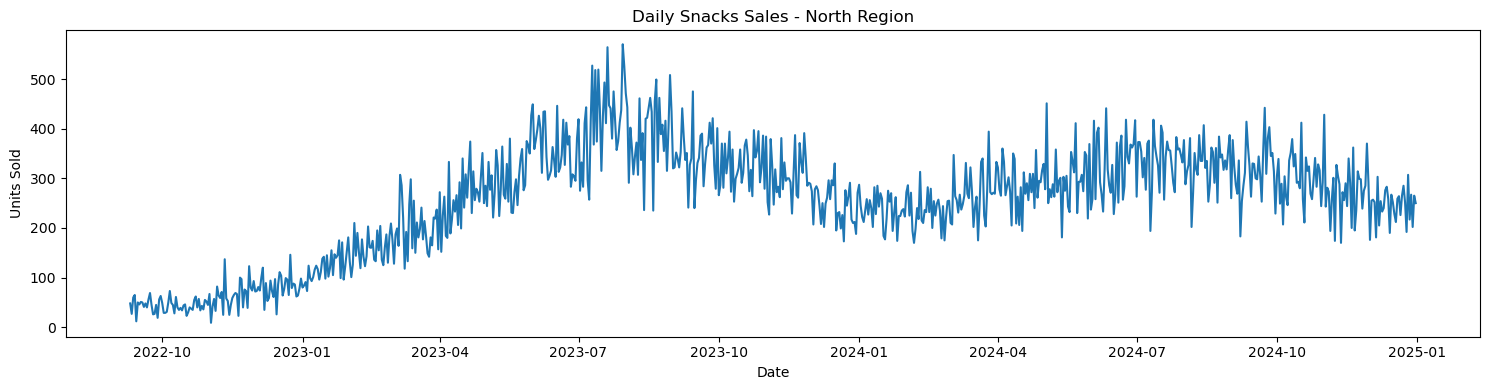

Total days of data: 843
Average daily units sold: 256.76
Max daily units sold: 570
Min daily units sold: 9


In [17]:
# ══════════════════════════════════════════════════════
# STEP 12 — Quick Sanity Check Before Prophet
# ══════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Plot daily sales for Snacks in North region
snacks_north = daily_sales[
    (daily_sales['category'] == 'Snacks') & 
    (daily_sales['region'] == 'North')
].copy()

plt.figure(figsize=(15, 4))
plt.plot(snacks_north['date'], snacks_north['units_sold'])
plt.title('Daily Snacks Sales - North Region')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.show()

print("Total days of data:", len(snacks_north))
print("Average daily units sold:", round(snacks_north['units_sold'].mean(), 2))
print("Max daily units sold:", snacks_north['units_sold'].max())
print("Min daily units sold:", snacks_north['units_sold'].min())

In [18]:
!pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 357.1 kB/s eta 0:00:33
   - -------------------------------------- 0.5/12.1 MB 357.1 kB/s eta 0:00:33
   -- ------------------------------------- 0.8/12.1 MB 486.4 kB/s eta 0:00:24
   --- ------------------------------------ 1.0/12.1 MB 572.0 kB/s eta 0:00:20
   --- ------------------------------------ 1.0/12.1 MB 572.0 kB/s eta 0:00:20
   ---- ----------------------------------- 1.3/12.1 MB 621.6 kB/s eta 0:00:18
   ----- ---------------------------------- 1.6/12.1 MB 671.1 kB/s eta 0:00:16
   ----- ------------------

In [19]:
# ══════════════════════════════════════════════════════
# STEP 13 — Prophet Forecast for Each Category x Region
# ══════════════════════════════════════════════════════

from prophet import Prophet
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Load data
daily_sales = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

event_master = pd.read_csv('../data/processed/event_master.csv')
event_master['date'] = pd.to_datetime(event_master['date'])

# Prepare holidays dataframe for Prophet
# Prophet needs columns: ds (date) and holiday (name)
holidays = event_master[['date', 'festival_name']].copy()
holidays.columns = ['ds', 'holiday']

print("Holidays sample:")
print(holidays.head())
print("\nUnique categories:", daily_sales['category'].unique())
print("Unique regions:", daily_sales['region'].unique())

Holidays sample:
          ds                    holiday
0 2022-01-01             New Year's Day
1 2022-01-09  Guru Govind Singh Jayanti
2 2022-01-13                      Lohri
3 2022-01-14            Makar Sankranti
4 2022-01-14                     Pongal

Unique categories: ['Dairy' 'Instant Food' 'Beverages' 'Snacks']
Unique regions: ['North' 'South' 'West']


In [20]:
# ══════════════════════════════════════════════════════
# STEP 14 — Run Prophet for All Category x Region
# ══════════════════════════════════════════════════════

forecasts = []

categories = daily_sales['category'].unique()
regions = daily_sales['region'].unique()

for category in categories:
    for region in regions:
        
        # Filter data for this category and region
        df = daily_sales[
            (daily_sales['category'] == category) &
            (daily_sales['region'] == region)
        ][['date', 'units_sold']].copy()
        
        # Prophet needs columns named ds and y
        df.columns = ['ds', 'y']
        df = df.sort_values('ds').reset_index(drop=True)
        
        # Skip if not enough data
        if len(df) < 100:
            print(f"Skipping {category} - {region}: not enough data")
            continue
        
        # Build and fit Prophet model
        model = Prophet(
            holidays=holidays,
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.05
        )
        
        model.fit(df)
        
        # Forecast next 30 days
        future = model.make_future_dataframe(periods=30)
        forecast = model.predict(future)
        
        # Keep only future dates (next 30 days)
        last_date = df['ds'].max()
        forecast_future = forecast[forecast['ds'] > last_date][[
            'ds', 'yhat', 'yhat_lower', 'yhat_upper'
        ]].copy()
        
        forecast_future['category'] = category
        forecast_future['region'] = region
        
        forecasts.append(forecast_future)
        print(f"Done: {category} - {region}")

# Combine all forecasts
forecast_df = pd.concat(forecasts, ignore_index=True)
forecast_df.columns = ['date', 'forecasted_demand', 'lower_bound', 'upper_bound', 'category', 'region']

# Round values
forecast_df['forecasted_demand'] = forecast_df['forecasted_demand'].round(0).astype(int)
forecast_df['lower_bound'] = forecast_df['lower_bound'].round(0).astype(int)
forecast_df['upper_bound'] = forecast_df['upper_bound'].round(0).astype(int)

print("\nForecast shape:", forecast_df.shape)
print("\nSample:")
print(forecast_df.head(10))

# Save
forecast_df.to_csv('../data/processed/forecast.csv', index=False)
print("\nSaved to data/processed/forecast.csv")

12:06:18 - cmdstanpy - INFO - Chain [1] start processing
12:06:19 - cmdstanpy - INFO - Chain [1] done processing


Done: Dairy - North


12:06:20 - cmdstanpy - INFO - Chain [1] start processing
12:06:20 - cmdstanpy - INFO - Chain [1] done processing


Done: Dairy - South


12:06:21 - cmdstanpy - INFO - Chain [1] start processing
12:06:21 - cmdstanpy - INFO - Chain [1] done processing


...

Done: Snacks - North


12:06:28 - cmdstanpy - INFO - Chain [1] start processing
12:06:29 - cmdstanpy - INFO - Chain [1] done processing


Done: Snacks - South


12:06:29 - cmdstanpy - INFO - Chain [1] start processing
12:06:30 - cmdstanpy - INFO - Chain [1] done processing


Done: Snacks - West

Forecast shape: (360, 6)

Sample:
        date  forecasted_demand  lower_bound  upper_bound category region
0 2025-01-01                662          561          775    Dairy  North
1 2025-01-02                666          553          765    Dairy  North
2 2025-01-03                668          564          771    Dairy  North
3 2025-01-04                674          574          771    Dairy  North
4 2025-01-05                674          560          774    Dairy  North
5 2025-01-06                676          570          785    Dairy  North
6 2025-01-07                659          556          770    Dairy  North
7 2025-01-08                663          559          772    Dairy  North
8 2025-01-09                669          570          774    Dairy  North
9 2025-01-10                673          567          784    Dairy  North

Saved to data/processed/forecast.csv


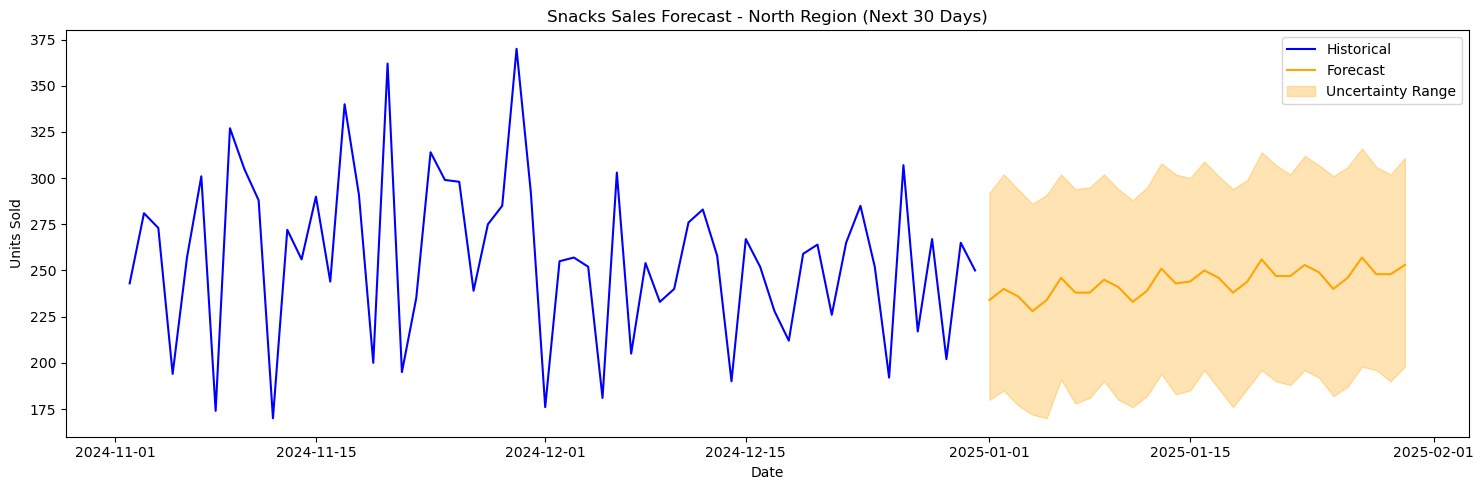

In [22]:
# ══════════════════════════════════════════════════════
# STEP 15 — Visualize Forecast
# ══════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Plot Snacks - North forecast
snacks_forecast = forecast_df[
    (forecast_df['category'] == 'Snacks') &
    (forecast_df['region'] == 'North')
].copy()

# Also get historical data for comparison
snacks_historical = daily_sales[
    (daily_sales['category'] == 'Snacks') &
    (daily_sales['region'] == 'North')
].tail(60)  # last 60 days

plt.figure(figsize=(15, 5))

# Plot historical
plt.plot(snacks_historical['date'], 
         snacks_historical['units_sold'], 
         label='Historical', color='blue')

# Plot forecast
plt.plot(snacks_forecast['date'], 
         snacks_forecast['forecasted_demand'], 
         label='Forecast', color='orange')

# Plot uncertainty band
plt.fill_between(snacks_forecast['date'],
                 snacks_forecast['lower_bound'],
                 snacks_forecast['upper_bound'],
                 alpha=0.3, color='orange', label='Uncertainty Range')

plt.title('Snacks Sales Forecast - North Region (Next 30 Days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# ══════════════════════════════════════════════════════
# STEP 16 — Generate Synthetic Stationery Data
# ══════════════════════════════════════════════════════

import numpy as np

np.random.seed(42)

# Date range matching our FMCG data
dates = pd.date_range(start='2022-01-21', end='2024-12-31', freq='D')
regions = ['North', 'South', 'West']

# Exam windows — stationery spikes 2 weeks before exam
exam_windows = [
    # Board exams
    ('2022-02-01', '2022-02-15'),
    ('2023-02-01', '2023-02-15'),
    ('2024-02-01', '2024-02-15'),
    # JEE
    ('2022-01-10', '2022-01-20'),
    ('2023-01-14', '2023-01-24'),
    ('2024-01-17', '2024-01-27'),
    # NEET
    ('2022-05-03', '2022-05-17'),
    ('2023-04-23', '2023-05-07'),
    ('2024-04-21', '2024-05-05'),
]

exam_dates = []
for start, end in exam_windows:
    exam_dates.extend(pd.date_range(start=start, end=end))
exam_dates = set(exam_dates)

stationery_rows = []

for region in regions:
    for date in dates:
        # Base sales
        base = np.random.normal(80, 15)
        
        # Exam spike — 2.5x during exam windows
        if date in exam_dates:
            base = base * 2.5
        
        # Back to school spike — June/July
        if date.month in [6, 7]:
            base = base * 1.8
        
        # Weekend slight dip (people study less on weekends?)
        if date.dayofweek >= 5:
            base = base * 0.85

        # Add some noise
        units = max(0, int(base + np.random.normal(0, 10)))

        stationery_rows.append({
            'date': date,
            'category': 'Stationery',
            'region': region,
            'units_sold': units,
            'stock_available': np.random.randint(200, 800),
            'avg_price': round(np.random.uniform(1.5, 5.0), 2),
            'promotion_flag': np.random.choice([0, 1], p=[0.85, 0.15])
        })

stationery_df = pd.DataFrame(stationery_rows)

print("Stationery data shape:", stationery_df.shape)
print("\nAverage daily sales by period:")
print("Normal days:", round(stationery_df[~stationery_df['date'].isin(exam_dates)]['units_sold'].mean(), 1))
print("Exam window:", round(stationery_df[stationery_df['date'].isin(exam_dates)]['units_sold'].mean(), 1))

# Append to daily_sales
daily_sales_full = pd.concat([daily_sales, stationery_df], ignore_index=True)
daily_sales_full.to_csv('../data/processed/daily_sales.csv', index=False)
print("\nSaved updated daily_sales with stationery")
print("New shape:", daily_sales_full.shape)

Stationery data shape: (3228, 7)

Average daily sales by period:
Normal days: 88.0
Exam window: 190.3

Saved updated daily_sales with stationery
New shape: (14661, 7)


In [24]:
# ══════════════════════════════════════════════════════
# STEP 17 — Run Prophet on Stationery
# ══════════════════════════════════════════════════════

stationery_forecasts = []

for region in ['North', 'South', 'West']:
    
    df = stationery_df[
        stationery_df['region'] == region
    ][['date', 'units_sold']].copy()
    
    df.columns = ['ds', 'y']
    df = df.sort_values('ds').reset_index(drop=True)
    
    model = Prophet(
        holidays=holidays,
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    
    model.fit(df)
    
    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)
    
    last_date = df['ds'].max()
    forecast_future = forecast[forecast['ds'] > last_date][[
        'ds', 'yhat', 'yhat_lower', 'yhat_upper'
    ]].copy()
    
    forecast_future['category'] = 'Stationery'
    forecast_future['region'] = region
    
    stationery_forecasts.append(forecast_future)
    print(f"Done: Stationery - {region}")

# Combine with existing forecast
stationery_forecast_df = pd.concat(stationery_forecasts, ignore_index=True)
stationery_forecast_df.columns = ['date', 'forecasted_demand', 'lower_bound', 'upper_bound', 'category', 'region']

# Round
stationery_forecast_df

12:10:07 - cmdstanpy - INFO - Chain [1] start processing
12:10:07 - cmdstanpy - INFO - Chain [1] done processing


Done: Stationery - North


12:10:07 - cmdstanpy - INFO - Chain [1] start processing
12:10:08 - cmdstanpy - INFO - Chain [1] done processing


Done: Stationery - South


12:10:08 - cmdstanpy - INFO - Chain [1] start processing
12:10:09 - cmdstanpy - INFO - Chain [1] done processing


Done: Stationery - West


,date,forecasted_demand,lower_bound,upper_bound,category,region
0,2025-01-01,95.559351,56.385707,134.672569,Stationery,North
1,2025-01-02,98.933560,60.294691,139.553597,Stationery,North
2,2025-01-03,100.237389,60.238846,140.348339,Stationery,North
3,2025-01-04,88.113660,47.998806,125.830098,Stationery,North
4,2025-01-05,87.874366,48.642963,128.603403,Stationery,North
...,...,...,...,...,...,...
85,2025-01-26,145.119215,109.745270,185.164254,Stationery,West
86,2025-01-27,160.073719,122.561819,199.444527,Stationery,West
87,2025-01-28,162.352993,124.265726,203.124086,Stationery,West
88,2025-01-29,162.569571,121.407352,200.268363,Stationery,West


In [25]:
# ══════════════════════════════════════════════════════
# STEP 18 — Fix Rounding and Save Final Forecast
# ══════════════════════════════════════════════════════

forecast_df_full['forecasted_demand'] = forecast_df_full['forecasted_demand'].round(0).astype(int)
forecast_df_full['lower_bound'] = forecast_df_full['lower_bound'].round(0).astype(int)
forecast_df_full['upper_bound'] = forecast_df_full['upper_bound'].round(0).astype(int)

print("Full forecast shape:", forecast_df_full.shape)
print("\nCategory breakdown:")
print(forecast_df_full['category'].value_counts())
print("\nSample:")
print(forecast_df_full.head(10))

# Save
forecast_df_full.to_csv('../data/processed/forecast.csv', index=False)
print("\nSaved final forecast.csv")

NameError: name 'forecast_df_full' is not defined

In [26]:
# ══════════════════════════════════════════════════════
# STEP 18 — Reload and Fix Forecast
# ══════════════════════════════════════════════════════

forecast_df_full = pd.read_csv('../data/processed/forecast.csv')
forecast_df_full['date'] = pd.to_datetime(forecast_df_full['date'])

forecast_df_full['forecasted_demand'] = forecast_df_full['forecasted_demand'].round(0).astype(int)
forecast_df_full['lower_bound'] = forecast_df_full['lower_bound'].round(0).astype(int)
forecast_df_full['upper_bound'] = forecast_df_full['upper_bound'].round(0).astype(int)

print("Full forecast shape:", forecast_df_full.shape)
print("\nCategory breakdown:")
print(forecast_df_full['category'].value_counts())
print("\nSample:")
print(forecast_df_full.head(10))

forecast_df_full.to_csv('../data/processed/forecast.csv', index=False)
print("\nSaved final forecast.csv")

Full forecast shape: (360, 6)

Category breakdown:
category
Dairy           90
Instant Food    90
Beverages       90
Snacks          90
Name: count, dtype: int64

Sample:
        date  forecasted_demand  lower_bound  upper_bound category region
0 2025-01-01                662          561          775    Dairy  North
1 2025-01-02                666          553          765    Dairy  North
2 2025-01-03                668          564          771    Dairy  North
3 2025-01-04                674          574          771    Dairy  North
4 2025-01-05                674          560          774    Dairy  North
5 2025-01-06                676          570          785    Dairy  North
6 2025-01-07                659          556          770    Dairy  North
7 2025-01-08                663          559          772    Dairy  North
8 2025-01-09                669          570          774    Dairy  North
9 2025-01-10                673          567          784    Dairy  North

Saved final fo

In [27]:
# ══════════════════════════════════════════════════════
# STEP 18 — Rebuild Full Forecast with Stationery
# ══════════════════════════════════════════════════════

# Reload base forecast
base_forecast = pd.read_csv('../data/processed/forecast.csv')
base_forecast['date'] = pd.to_datetime(base_forecast['date'])

# Combine with stationery forecast from memory
stationery_forecast_df['date'] = pd.to_datetime(stationery_forecast_df['date'])
stationery_forecast_df['forecasted_demand'] = stationery_forecast_df['forecasted_demand'].round(0).astype(int)
stationery_forecast_df['lower_bound'] = stationery_forecast_df['lower_bound'].round(0).astype(int)
stationery_forecast_df['upper_bound'] = stationery_forecast_df['upper_bound'].round(0).astype(int)

# Combine
forecast_df_full = pd.concat([base_forecast, stationery_forecast_df], ignore_index=True)

print("Full forecast shape:", forecast_df_full.shape)
print("\nCategory breakdown:")
print(forecast_df_full['category'].value_counts())

# Save
forecast_df_full.to_csv('../data/processed/forecast.csv', index=False)
print("\nSaved final forecast.csv")

Full forecast shape: (450, 6)

Category breakdown:
category
Dairy           90
Instant Food    90
Beverages       90
Snacks          90
Stationery      90
Name: count, dtype: int64

Saved final forecast.csv


In [28]:
# ══════════════════════════════════════════════════════
# STEP 19 — Generate Inventory Data
# ══════════════════════════════════════════════════════

np.random.seed(42)

# Base current stock — derived from last 7 days average of stock_available
daily_sales_full = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales_full['date'] = pd.to_datetime(daily_sales_full['date'])

# Get last 7 days average stock per category per region
last_7_days = daily_sales_full[
    daily_sales_full['date'] >= daily_sales_full['date'].max() - pd.Timedelta(days=7)
]

current_stock = last_7_days.groupby(
    ['category', 'region']
)['stock_available'].mean().round(0).astype(int).reset_index()

current_stock.columns = ['category', 'region', 'current_stock']

# Add supply chain constraints per category
constraints = {
    'Snacks':       {'shelf_life': 90,  'lead_time': 2, 'max_capacity': 5000},
    'Beverages':    {'shelf_life': 180, 'lead_time': 2, 'max_capacity': 4000},
    'Dairy':        {'shelf_life': 7,   'lead_time': 1, 'max_capacity': 3000},
    'Instant Food': {'shelf_life': 365, 'lead_time': 3, 'max_capacity': 4000},
    'Stationery':   {'shelf_life': 730, 'lead_time': 3, 'max_capacity': 6000},
}

# Add cost and price per category
financials = {
    'Snacks':       {'unit_cost': 15, 'selling_price': 25, 'salvage_value': 5},
    'Beverages':    {'unit_cost': 20, 'selling_price': 35, 'salvage_value': 8},
    'Dairy':        {'unit_cost': 40, 'selling_price': 60, 'salvage_value': 10},
    'Instant Food': {'unit_cost': 30, 'selling_price': 50, 'salvage_value': 10},
    'Stationery':   {'unit_cost': 10, 'selling_price': 20, 'salvage_value': 3},
}

# Build inventory dataframe
inventory_rows = []
for _, row in current_stock.iterrows():
    cat = row['category']
    c = constraints[cat]
    f = financials[cat]
    inventory_rows.append({
        'category':         cat,
        'region':           row['region'],
        'current_stock':    row['current_stock'],
        'max_capacity':     c['max_capacity'],
        'shelf_life_days':  c['shelf_life'],
        'lead_time_days':   c['lead_time'],
        'unit_cost':        f['unit_cost'],
        'selling_price':    f['selling_price'],
        'salvage_value':    f['salvage_value'],
    })

inventory_df = pd.DataFrame(inventory_rows)

print("Inventory shape:", inventory_df.shape)
print("\nInventory data:")
print(inventory_df.to_string(index=False))

# Save
inventory_df.to_csv('../data/processed/inventory.csv', index=False)
print("\nSaved inventory.csv")

Inventory shape: (15, 9)

Inventory data:
    category region  current_stock  max_capacity  shelf_life_days  lead_time_days  unit_cost  selling_price  salvage_value
   Beverages  North            441          4000              180               2         20             35              8
   Beverages  South            402          4000              180               2         20             35              8
   Beverages   West            333          4000              180               2         20             35              8
       Dairy  North           7374          3000                7               1         40             60             10
       Dairy  South           6983          3000                7               1         40             60             10
       Dairy   West           7478          3000                7               1         40             60             10
Instant Food  North           1977          4000              365               3         30     

In [29]:
# ══════════════════════════════════════════════════════
# STEP 20 — Newsvendor Model + Alert Engine
# ══════════════════════════════════════════════════════

# Load all data
forecast_df_full = pd.read_csv('../data/processed/forecast.csv')
inventory_df = pd.read_csv('../data/processed/inventory.csv')
event_master_final = pd.read_csv('../data/processed/event_master.csv')

forecast_df_full['date'] = pd.to_datetime(forecast_df_full['date'])
event_master_final['date'] = pd.to_datetime(event_master_final['date'])

# ── Newsvendor Critical Ratio ──────────────────────
# Critical Ratio = (Price - Cost) / (Price - Salvage)
# This tells us how much buffer stock to carry

def critical_ratio(selling_price, unit_cost, salvage_value):
    return (selling_price - unit_cost) / (selling_price - salvage_value)

# Add critical ratio to inventory
inventory_df['critical_ratio'] = inventory_df.apply(
    lambda r: critical_ratio(r['selling_price'], r['unit_cost'], r['salvage_value']),
    axis=1
)

print("Critical ratios by category:")
print(inventory_df[['category', 'critical_ratio']].drop_duplicates().to_string(index=False))

Critical ratios by category:
    category  critical_ratio
   Beverages        0.555556
       Dairy        0.400000
Instant Food        0.500000
      Snacks        0.500000
  Stationery        0.588235


In [3]:
# ══════════════════════════════════════════════════════
# STEP 21 — Event Sensitivity Mapping
# ══════════════════════════════════════════════════════

# Which categories spike on which event types
event_sensitivity = {
    'IPL':      ['Snacks', 'Beverages'],
    'Festival': ['Snacks', 'Beverages', 'Dairy', 'Instant Food'],
    'Exam':     ['Stationery', 'Instant Food'],
}

# Spike multiplier by importance
importance_multiplier = {
    'Very High': 2.5,
    'High':      1.8,
    'Medium':    1.3,
}

# Build alerts
alerts = []

for _, event in event_master_final.iterrows():
    event_date = event['date']
    event_type = event['event_type']
    event_region = event['region']
    importance = event['importance']
    event_name = event['festival_name']

    # Get sensitive categories for this event type
    sensitive_cats = event_sensitivity.get(event_type, [])

    for category in sensitive_cats:

        # Get regions to alert
        if event_region == 'All':
            regions = ['North', 'South', 'West']
        else:
            regions = [event_region]

        for region in regions:

            # Get forecast for this date
            fc = forecast_df_full[
                (forecast_df_full['date'] == event_date) &
                (forecast_df_full['category'] == category) &
                (forecast_df_full['region'] == region)
            ]

            if fc.empty:
                continue

            base_demand = fc['forecasted_demand'].values[0]

            # Apply spike multiplier
            multiplier = importance_multiplier.get(importance, 1.3)
            predicted_demand = int(base_demand * multiplier)

            # Get inventory for this category and region
            inv = inventory_df[
                (inventory_df['category'] == category) &
                (inventory_df['region'] == region)
            ]

            if inv.empty:
                continue

            current_stock = inv['current_stock'].values[0]
            max_capacity = inv['max_capacity'].values[0]
            shelf_life = inv['shelf_life_days'].values[0]
            lead_time = inv['lead_time_days'].values[0]
            cr = inv['critical_ratio'].values[0]

            # Newsvendor adjustment
            optimal_stock = int(predicted_demand * (1 + cr))

            # Order quantity
            order_qty = max(0, optimal_stock - current_stock)

            # Capacity constraint
            order_qty = min(order_qty, max_capacity - current_stock)
            order_qty = max(0, order_qty)

            # Shelf life constraint
            # Dont alert if event is further than shelf life
            days_to_event = (event_date - pd.Timestamp.today()).days
            if days_to_event > shelf_life:
                continue
            if days_to_event < 0:
                continue

            # Order by date
            order_by_date = event_date - pd.Timedelta(days=lead_time)

            # Urgency
            if days_to_event <= 3:
                urgency = 'HIGH'
            elif days_to_event <= 7:
                urgency = 'MEDIUM'
            elif days_to_event <= 14:
                urgency = 'LOW'
            else:
                urgency = 'PLAN AHEAD'

            alerts.append({
                'event_name':       event_name,
                'event_date':       event_date.date(),
                'event_type':       event_type,
                'region':           region,
                'category':         category,
                'base_demand':      base_demand,
                'spike_multiplier': multiplier,
                'predicted_demand': predicted_demand,
                'current_stock':    current_stock,
                'order_quantity':   order_qty,
                'order_by_date':    order_by_date.date(),
                'days_to_event':    days_to_event,
                'urgency':          urgency,
            })

alerts_df = pd.DataFrame(alerts)

print("Total alerts generated:", len(alerts_df))
print("\nUrgency breakdown:")
print(alerts_df['urgency'].value_counts())
print("\nCategory breakdown:")
print(alerts_df['category'].value_counts())
print("\nSample alerts:")
print(alerts_df[alerts_df['order_quantity'] > 0].head(10).to_string(index=False))

Total alerts generated: 0

Urgency breakdown:


KeyError: 'urgency'

In [4]:
print("Forecast date range:")
print(forecast_df_full['date'].min(), "to", forecast_df_full['date'].max())

print("\nEvent date range:")
print(event_master_final['date'].min(), "to", event_master_final['date'].max())

print("\nToday:", pd.Timestamp.today().date())

Forecast date range:
2025-01-01 00:00:00 to 2025-01-30 00:00:00

Event date range:
2022-01-01 00:00:00 to 2024-12-29 00:00:00

Today: 2026-07-15


In [2]:
# ══════════════════════════════════════════════════════
# STEP 20 — Reload All Data
# ══════════════════════════════════════════════════════

import pandas as pd
import numpy as np

forecast_df_full = pd.read_csv('../data/processed/forecast.csv')
inventory_df = pd.read_csv('../data/processed/inventory.csv')
event_master_final = pd.read_csv('../data/processed/event_master.csv')

forecast_df_full['date'] = pd.to_datetime(forecast_df_full['date'])
event_master_final['date'] = pd.to_datetime(event_master_final['date'])

# Critical ratio function
def critical_ratio(selling_price, unit_cost, salvage_value):
    return (selling_price - unit_cost) / (selling_price - salvage_value)

inventory_df['critical_ratio'] = inventory_df.apply(
    lambda r: critical_ratio(r['selling_price'], r['unit_cost'], r['salvage_value']),
    axis=1
)

print("All data reloaded successfully")
print("Forecast shape:", forecast_df_full.shape)
print("Inventory shape:", inventory_df.shape)
print("Events shape:", event_master_final.shape)

All data reloaded successfully
Forecast shape: (450, 6)
Inventory shape: (15, 10)
Events shape: (426, 5)


In [5]:
# ══════════════════════════════════════════════════════
# FIX — Extend Event Master to 2025 and 2026
# ══════════════════════════════════════════════════════

event_master_final = pd.read_csv('../data/processed/event_master.csv')
event_master_final['date'] = pd.to_datetime(event_master_final['date'])

# Separate IPL and non-IPL
ipl_events = event_master_final[event_master_final['event_type'] == 'IPL'].copy()
non_ipl_events = event_master_final[event_master_final['event_type'] != 'IPL'].copy()

# Extend non-IPL events to 2025 and 2026
non_ipl_2025 = non_ipl_events.copy()
non_ipl_2025['date'] = non_ipl_events['date'] + pd.DateOffset(years=3)

non_ipl_2026 = non_ipl_events.copy()
non_ipl_2026['date'] = non_ipl_events['date'] + pd.DateOffset(years=4)

# Hardcode correct lunar festival dates for 2025 and 2026
lunar_corrections = [
    # 2025
    {'date': '2025-03-14', 'festival_name': 'Holi',              'region': 'All',   'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2025-03-31', 'festival_name': 'Eid al-Fitr',       'region': 'All',   'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2025-10-20', 'festival_name': 'Diwali',            'region': 'All',   'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2025-08-27', 'festival_name': 'Raksha Bandhan',    'region': 'North', 'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2025-08-27', 'festival_name': 'Ganesh Chaturthi',  'region': 'West',  'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2025-09-22', 'festival_name': 'Navratri',          'region': 'West',  'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2025-09-28', 'festival_name': 'Durga Puja',        'region': 'East',  'event_type': 'Festival', 'importance': 'Very High'},
    # 2026
    {'date': '2026-03-03', 'festival_name': 'Holi',              'region': 'All',   'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2026-03-20', 'festival_name': 'Eid al-Fitr',       'region': 'All',   'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2026-11-08', 'festival_name': 'Diwali',            'region': 'All',   'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2026-08-17', 'festival_name': 'Raksha Bandhan',    'region': 'North', 'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2026-08-22', 'festival_name': 'Ganesh Chaturthi',  'region': 'West',  'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2026-10-10', 'festival_name': 'Navratri',          'region': 'West',  'event_type': 'Festival', 'importance': 'Very High'},
    {'date': '2026-10-16', 'festival_name': 'Durga Puja',        'region': 'East',  'event_type': 'Festival', 'importance': 'Very High'},
]

lunar_df = pd.DataFrame(lunar_corrections)
lunar_df['date'] = pd.to_datetime(lunar_df['date'])

# Remove old lunar festivals from extended data
lunar_names = ['Holi', 'Eid al-Fitr', 'Diwali', 'Raksha Bandhan', 
               'Ganesh Chaturthi', 'Navratri', 'Durga Puja']

non_ipl_2025 = non_ipl_2025[~non_ipl_2025['festival_name'].isin(lunar_names)]
non_ipl_2026 = non_ipl_2026[~non_ipl_2026['festival_name'].isin(lunar_names)]

# Add IPL 2025 and 2026 approximate dates (March-May season)
ipl_2025 = pd.DataFrame([
    {'date': pd.to_datetime(f'2025-{m:02d}-{d:02d}'), 
     'festival_name': f'IPL Match', 
     'region': r, 
     'event_type': 'IPL', 
     'importance': 'Medium'}
    for m, d, r in [
        (3,22,'West'),(3,23,'South'),(3,25,'North'),(3,26,'West'),
        (3,28,'East'),(3,29,'South'),(3,30,'North'),(4,1,'West'),
        (4,3,'South'),(4,5,'North'),(4,6,'West'),(4,8,'East'),
        (4,10,'South'),(4,12,'North'),(4,13,'West'),(4,15,'South'),
        (4,17,'North'),(4,19,'West'),(4,20,'East'),(4,22,'South'),
        (4,24,'North'),(4,26,'West'),(4,27,'South'),(4,29,'North'),
        (5,1,'West'),(5,3,'South'),(5,4,'North'),(5,6,'West'),
        (5,8,'South'),(5,10,'North'),(5,11,'West'),(5,13,'South'),
        (5,15,'North'),(5,17,'West'),(5,18,'South'),(5,20,'North'),
        (5,22,'West'),(5,24,'South'),(5,25,'North'),
        # Playoffs
        (5,27,'West'),(5,28,'South'),(5,30,'North'),
    ]
])

# IPL Final 2025
ipl_2025_final = pd.DataFrame([{
    'date': pd.to_datetime('2025-06-01'),
    'festival_name': 'IPL Final',
    'region': 'West',
    'event_type': 'IPL',
    'importance': 'Very High'
}])

# IPL 2026 (approximate July season - ongoing now)
ipl_2026 = pd.DataFrame([
    {'date': pd.to_datetime(f'2026-{m:02d}-{d:02d}'),
     'festival_name': 'IPL Match',
     'region': r,
     'event_type': 'IPL',
     'importance': 'Medium'}
    for m, d, r in [
        (7,15,'West'),(7,16,'South'),(7,18,'North'),(7,19,'West'),
        (7,21,'East'),(7,22,'South'),(7,24,'North'),(7,25,'West'),
        (7,27,'South'),(7,28,'North'),(7,30,'West'),(7,31,'South'),
        (8,1,'North'),(8,2,'West'),(8,3,'South'),(8,5,'North'),
    ]
])

# Combine everything
event_master_updated = pd.concat([
    event_master_final,
    non_ipl_2025, non_ipl_2026,
    lunar_df,
    ipl_2025, ipl_2025_final,
    ipl_2026
], ignore_index=True).sort_values('date').reset_index(drop=True)

# Filter only future events (from today)
today = pd.Timestamp.today()
event_master_updated = event_master_updated[event_master_updated['date'] >= today]

print("Updated event master shape:", event_master_updated.shape)
print("\nEvent type distribution:")
print(event_master_updated['event_type'].value_counts())
print("\nUpcoming events sample:")
print(event_master_updated.head(15).to_string(index=False))

# Save
event_master_updated.to_csv('../data/processed/event_master.csv', index=False)
print("\nSaved updated event_master.csv")

Updated event master shape: (262, 5)

Event type distribution:
event_type
Festival    238
IPL          15
Exam          9
Name: count, dtype: int64

Upcoming events sample:
      date festival_name region event_type importance
2026-07-16     IPL Match  South        IPL     Medium
2026-07-18     IPL Match  North        IPL     Medium
2026-07-19     IPL Match   West        IPL     Medium
2026-07-21     IPL Match   East        IPL     Medium
2026-07-22     IPL Match  South        IPL     Medium
2026-07-24     IPL Match  North        IPL     Medium
2026-07-25     IPL Match   West        IPL     Medium
2026-07-27     IPL Match  South        IPL     Medium
2026-07-28     IPL Match  North        IPL     Medium
2026-07-30     IPL Match   West        IPL     Medium
2026-07-31     IPL Match  South        IPL     Medium
2026-08-01     IPL Match  North        IPL     Medium
2026-08-02     IPL Match   West        IPL     Medium
2026-08-03     IPL Match  South        IPL     Medium
2026-08-05     IP

In [6]:
# ══════════════════════════════════════════════════════
# FIX — Re-run Prophet for Next 30 Days from Today
# ══════════════════════════════════════════════════════

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

daily_sales_full = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales_full['date'] = pd.to_datetime(daily_sales_full['date'])

# Prepare holidays for Prophet
event_all = pd.read_csv('../data/processed/event_master.csv')
event_all['date'] = pd.to_datetime(event_all['date'])

holidays = event_master_final[['date', 'festival_name']].copy()
holidays.columns = ['ds', 'holiday']

forecasts = []
categories = daily_sales_full['category'].unique()
regions = ['North', 'South', 'West']

for category in categories:
    for region in regions:

        df = daily_sales_full[
            (daily_sales_full['category'] == category) &
            (daily_sales_full['region'] == region)
        ][['date', 'units_sold']].copy()

        df.columns = ['ds', 'y']
        df = df.sort_values('ds').reset_index(drop=True)

        if len(df) < 100:
            print(f"Skipping {category} - {region}: not enough data")
            continue

        model = Prophet(
            holidays=holidays,
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.05
        )

        model.fit(df)

        # Forecast from today to next 30 days
        today = pd.Timestamp.today()
        future_dates = pd.date_range(start=today, periods=30, freq='D')
        future = pd.DataFrame({'ds': future_dates})

        forecast = model.predict(future)

        forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        forecast_out['category'] = category
        forecast_out['region'] = region

        forecasts.append(forecast_out)
        print(f"Done: {category} - {region}")

forecast_df_full = pd.concat(forecasts, ignore_index=True)
forecast_df_full.columns = ['date', 'forecasted_demand', 'lower_bound', 'upper_bound', 'category', 'region']

# Round and clip negatives
forecast_df_full['forecasted_demand'] = forecast_df_full['forecasted_demand'].round(0).clip(lower=0).astype(int)
forecast_df_full['lower_bound'] = forecast_df_full['lower_bound'].round(0).clip(lower=0).astype(int)
forecast_df_full['upper_bound'] = forecast_df_full['upper_bound'].round(0).clip(lower=0).astype(int)

print("\nForecast shape:", forecast_df_full.shape)
print("\nDate range:", forecast_df_full['date'].min(), "to", forecast_df_full['date'].max())
print("\nCategory breakdown:")
print(forecast_df_full['category'].value_counts())

forecast_df_full.to_csv('../data/processed/forecast.csv', index=False)
print("\nSaved updated forecast.csv")

11:30:02 - cmdstanpy - INFO - Chain [1] start processing
11:30:03 - cmdstanpy - INFO - Chain [1] done processing


Done: Dairy - North


11:30:04 - cmdstanpy - INFO - Chain [1] start processing
11:30:05 - cmdstanpy - INFO - Chain [1] done processing


Done: Dairy - South


11:30:05 - cmdstanpy - INFO - Chain [1] start processing
11:30:06 - cmdstanpy - INFO - Chain [1] done processing


...

Done: Stationery - North


11:30:17 - cmdstanpy - INFO - Chain [1] start processing
11:30:18 - cmdstanpy - INFO - Chain [1] done processing


Done: Stationery - South


11:30:18 - cmdstanpy - INFO - Chain [1] start processing
11:30:19 - cmdstanpy - INFO - Chain [1] done processing


Done: Stationery - West

Forecast shape: (450, 6)

Date range: 2026-07-15 11:30:03.965830 to 2026-08-13 11:30:19.473688

Category breakdown:
category
Dairy           90
Instant Food    90
Beverages       90
Snacks          90
Stationery      90
Name: count, dtype: int64

Saved updated forecast.csv


In [7]:
# ══════════════════════════════════════════════════════
# STEP 21 — Alert Engine
# ══════════════════════════════════════════════════════

event_master_final = pd.read_csv('../data/processed/event_master.csv')
event_master_final['date'] = pd.to_datetime(event_master_final['date'])

event_sensitivity = {
    'IPL':      ['Snacks', 'Beverages'],
    'Festival': ['Snacks', 'Beverages', 'Dairy', 'Instant Food'],
    'Exam':     ['Stationery', 'Instant Food'],
}

importance_multiplier = {
    'Very High': 2.5,
    'High':      1.8,
    'Medium':    1.3,
}

alerts = []

for _, event in event_master_final.iterrows():
    event_date = event['date']
    event_type = event['event_type']
    event_region = event['region']
    importance = event['importance']
    event_name = event['festival_name']

    sensitive_cats = event_sensitivity.get(event_type, [])

    for category in sensitive_cats:

        if event_region == 'All':
            regions = ['North', 'South', 'West']
        else:
            regions = [event_region]

        for region in regions:

            fc = forecast_df_full[
                (forecast_df_full['date'].dt.date == event_date.date()) &
                (forecast_df_full['category'] == category) &
                (forecast_df_full['region'] == region)
            ]

            if fc.empty:
                continue

            base_demand = fc['forecasted_demand'].values[0]
            multiplier = importance_multiplier.get(importance, 1.3)
            predicted_demand = int(base_demand * multiplier)

            inv = inventory_df[
                (inventory_df['category'] == category) &
                (inventory_df['region'] == region)
            ]

            if inv.empty:
                continue

            current_stock = inv['current_stock'].values[0]
            max_capacity = inv['max_capacity'].values[0]
            shelf_life = inv['shelf_life_days'].values[0]
            lead_time = inv['lead_time_days'].values[0]
            cr = inv['critical_ratio'].values[0]

            optimal_stock = int(predicted_demand * (1 + cr))
            order_qty = max(0, optimal_stock - current_stock)
            order_qty = min(order_qty, max_capacity - current_stock)
            order_qty = max(0, order_qty)

            days_to_event = (event_date - pd.Timestamp.today()).days
            if days_to_event > shelf_life or days_to_event < 0:
                continue

            order_by_date = event_date - pd.Timedelta(days=lead_time)

            if days_to_event <= 3:
                urgency = 'HIGH'
            elif days_to_event <= 7:
                urgency = 'MEDIUM'
            elif days_to_event <= 14:
                urgency = 'LOW'
            else:
                urgency = 'PLAN AHEAD'

            alerts.append({
                'event_name':       event_name,
                'event_date':       event_date.date(),
                'event_type':       event_type,
                'region':           region,
                'category':         category,
                'base_demand':      base_demand,
                'spike_multiplier': multiplier,
                'predicted_demand': predicted_demand,
                'current_stock':    current_stock,
                'order_quantity':   order_qty,
                'order_by_date':    order_by_date.date(),
                'days_to_event':    days_to_event,
                'urgency':          urgency,
            })

alerts_df = pd.DataFrame(alerts)

print("Total alerts generated:", len(alerts_df))
print("\nUrgency breakdown:")
print(alerts_df['urgency'].value_counts())
print("\nCategory breakdown:")
print(alerts_df['category'].value_counts())
print("\nSample HIGH urgency alerts:")
print(alerts_df[alerts_df['urgency'] == 'HIGH'].head(10).to_string(index=False))

alerts_df.to_csv('../outputs/restock_alerts.csv', index=False)
print("\nSaved restock_alerts.csv")

Total alerts generated: 52

Urgency breakdown:
urgency
PLAN AHEAD    34
LOW           10
HIGH           6
MEDIUM         2
Name: count, dtype: int64

Category breakdown:
category
Snacks          22
Beverages       22
Instant Food     8
Name: count, dtype: int64

Sample HIGH urgency alerts:
event_name event_date event_type region  category  base_demand  spike_multiplier  predicted_demand  current_stock  order_quantity order_by_date  days_to_event urgency
 IPL Match 2026-07-16        IPL  South    Snacks          400               1.3               520           2382               0    2026-07-14              0    HIGH
 IPL Match 2026-07-16        IPL  South Beverages           35               1.3                45            402               0    2026-07-14              0    HIGH
 IPL Match 2026-07-18        IPL  North    Snacks          408               1.3               530           2381               0    2026-07-16              2    HIGH
 IPL Match 2026-07-18        IPL  North B

In [8]:
# ══════════════════════════════════════════════════════
# FIX — Realistic Dark Store Inventory Levels
# ══════════════════════════════════════════════════════

# Dark stores carry 3-5 days of stock, not weeks
# Recalculate current stock as 3 days of average daily sales

daily_sales_full = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales_full['date'] = pd.to_datetime(daily_sales_full['date'])

# Get average daily sales per category per region
avg_daily = daily_sales_full.groupby(
    ['category', 'region']
)['units_sold'].mean().round(0).astype(int).reset_index()

avg_daily.columns = ['category', 'region', 'avg_daily_sales']

# Current stock = 3 days of average sales (realistic dark store)
avg_daily['current_stock'] = (avg_daily['avg_daily_sales'] * 3).astype(int)

# Merge with existing inventory
inventory_df = inventory_df.drop(columns=['current_stock'])
inventory_df = inventory_df.merge(avg_daily[['category', 'region', 'current_stock']], 
                                   on=['category', 'region'])

print("Updated inventory:")
print(inventory_df[['category', 'region', 'current_stock', 'max_capacity']].to_string(index=False))

# Save
inventory_df.to_csv('../data/processed/inventory.csv', index=False)
print("\nSaved updated inventory.csv")

Updated inventory:
    category region  current_stock  max_capacity
   Beverages  North            141          4000
   Beverages  South            138          4000
   Beverages   West            135          4000
       Dairy  North           2190          3000
       Dairy  South           2181          3000
       Dairy   West           2178          3000
Instant Food  North            684          4000
Instant Food  South            690          4000
Instant Food   West            684          4000
      Snacks  North            771          5000
      Snacks  South            768          5000
      Snacks   West            765          5000
  Stationery  North            300          6000
  Stationery  South            294          6000
  Stationery   West            294          6000

Saved updated inventory.csv


In [9]:
# ══════════════════════════════════════════════════════
# STEP 21 — Re-run Alert Engine with Updated Inventory
# ══════════════════════════════════════════════════════

inventory_df = pd.read_csv('../data/processed/inventory.csv')

def critical_ratio(selling_price, unit_cost, salvage_value):
    return (selling_price - unit_cost) / (selling_price - salvage_value)

inventory_df['critical_ratio'] = inventory_df.apply(
    lambda r: critical_ratio(r['selling_price'], r['unit_cost'], r['salvage_value']),
    axis=1
)

event_sensitivity = {
    'IPL':      ['Snacks', 'Beverages'],
    'Festival': ['Snacks', 'Beverages', 'Dairy', 'Instant Food'],
    'Exam':     ['Stationery', 'Instant Food'],
}

importance_multiplier = {
    'Very High': 2.5,
    'High':      1.8,
    'Medium':    1.3,
}

alerts = []

for _, event in event_master_final.iterrows():
    event_date = event['date']
    event_type = event['event_type']
    event_region = event['region']
    importance = event['importance']
    event_name = event['festival_name']

    sensitive_cats = event_sensitivity.get(event_type, [])

    for category in sensitive_cats:

        if event_region == 'All':
            regions = ['North', 'South', 'West']
        else:
            regions = [event_region]

        for region in regions:

            fc = forecast_df_full[
                (forecast_df_full['date'].dt.date == event_date.date()) &
                (forecast_df_full['category'] == category) &
                (forecast_df_full['region'] == region)
            ]

            if fc.empty:
                continue

            base_demand = fc['forecasted_demand'].values[0]
            multiplier = importance_multiplier.get(importance, 1.3)
            predicted_demand = int(base_demand * multiplier)

            inv = inventory_df[
                (inventory_df['category'] == category) &
                (inventory_df['region'] == region)
            ]

            if inv.empty:
                continue

            current_stock = inv['current_stock'].values[0]
            max_capacity = inv['max_capacity'].values[0]
            shelf_life = inv['shelf_life_days'].values[0]
            lead_time = inv['lead_time_days'].values[0]
            cr = inv['critical_ratio'].values[0]

            optimal_stock = int(predicted_demand * (1 + cr))
            order_qty = max(0, optimal_stock - current_stock)
            order_qty = min(order_qty, max_capacity - current_stock)
            order_qty = max(0, order_qty)

            days_to_event = (event_date - pd.Timestamp.today()).days
            if days_to_event > shelf_life or days_to_event < 0:
                continue

            order_by_date = event_date - pd.Timedelta(days=lead_time)

            if days_to_event <= 3:
                urgency = 'HIGH'
            elif days_to_event <= 7:
                urgency = 'MEDIUM'
            elif days_to_event <= 14:
                urgency = 'LOW'
            else:
                urgency = 'PLAN AHEAD'

            alerts.append({
                'event_name':        event_name,
                'event_date':        event_date.date(),
                'event_type':        event_type,
                'region':            region,
                'category':          category,
                'base_demand':       base_demand,
                'spike_multiplier':  multiplier,
                'predicted_demand':  predicted_demand,
                'current_stock':     current_stock,
                'order_quantity':    order_qty,
                'order_by_date':     order_by_date.date(),
                'days_to_event':     days_to_event,
                'urgency':           urgency,
            })

alerts_df = pd.DataFrame(alerts)

print("Total alerts generated:", len(alerts_df))
print("\nUrgency breakdown:")
print(alerts_df['urgency'].value_counts())
print("\nAlerts with order_quantity > 0:", len(alerts_df[alerts_df['order_quantity'] > 0]))
print("\nSample alerts with orders needed:")
print(alerts_df[alerts_df['order_quantity'] > 0].head(10).to_string(index=False))

alerts_df.to_csv('../outputs/restock_alerts.csv', index=False)
print("\nSaved restock_alerts.csv")

Total alerts generated: 52

Urgency breakdown:
urgency
PLAN AHEAD    34
LOW           10
HIGH           6
MEDIUM         2
Name: count, dtype: int64

Alerts with order_quantity > 0: 14

Sample alerts with orders needed:
     event_name event_date event_type region category  base_demand  spike_multiplier  predicted_demand  current_stock  order_quantity order_by_date  days_to_event    urgency
      IPL Match 2026-07-16        IPL  South   Snacks          400               1.3               520            768              12    2026-07-14              0       HIGH
      IPL Match 2026-07-18        IPL  North   Snacks          408               1.3               530            771              24    2026-07-16              2       HIGH
      IPL Match 2026-07-22        IPL  South   Snacks          397               1.3               516            768               6    2026-07-20              6     MEDIUM
      IPL Match 2026-07-24        IPL  North   Snacks          405               1.3

In [10]:
# ══════════════════════════════════════════════════════
# STEP 22 — Clean and Save Final Alerts
# ══════════════════════════════════════════════════════

# Keep only alerts where order is actually needed
final_alerts = alerts_df[alerts_df['order_quantity'] > 0].copy()

# Remove duplicates
final_alerts = final_alerts.drop_duplicates()

# Sort by urgency then date
urgency_order = {'HIGH': 1, 'MEDIUM': 2, 'LOW': 3, 'PLAN AHEAD': 4}
final_alerts['urgency_rank'] = final_alerts['urgency'].map(urgency_order)
final_alerts = final_alerts.sort_values(
    ['urgency_rank', 'event_date']
).drop(columns=['urgency_rank']).reset_index(drop=True)

print("Final alerts shape:", final_alerts.shape)
print("\nUrgency breakdown:")
print(final_alerts['urgency'].value_counts())
print("\nFull alerts table:")
print(final_alerts.to_string(index=False))

final_alerts.to_csv('../outputs/restock_alerts.csv', index=False)
print("\nSaved final restock_alerts.csv")

Final alerts shape: (10, 13)

Urgency breakdown:
urgency
PLAN AHEAD    4
LOW           3
HIGH          2
MEDIUM        1
Name: count, dtype: int64

Full alerts table:
            event_name event_date event_type region category  base_demand  spike_multiplier  predicted_demand  current_stock  order_quantity order_by_date  days_to_event    urgency
             IPL Match 2026-07-16        IPL  South   Snacks          400               1.3               520            768              12    2026-07-14              0       HIGH
             IPL Match 2026-07-18        IPL  North   Snacks          408               1.3               530            771              24    2026-07-16              2       HIGH
             IPL Match 2026-07-22        IPL  South   Snacks          397               1.3               516            768               6    2026-07-20              6     MEDIUM
             IPL Match 2026-07-24        IPL  North   Snacks          405               1.3               526

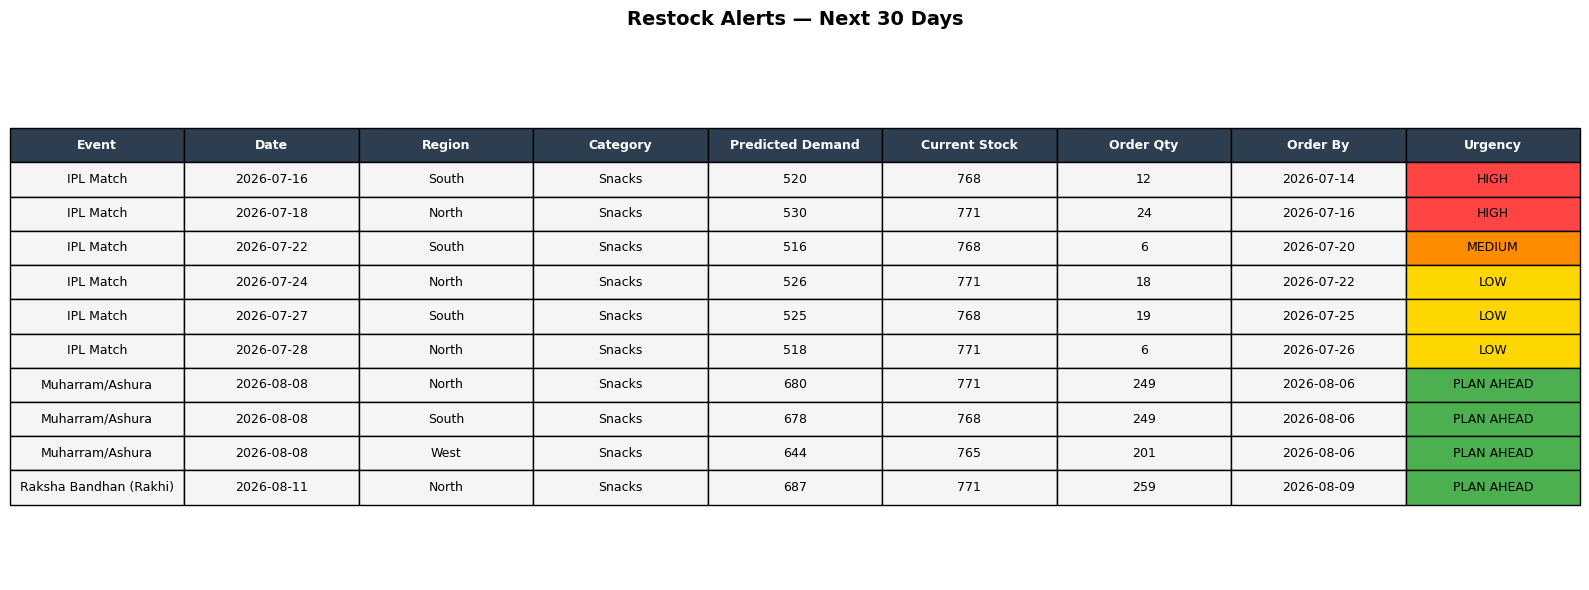

Chart 1 saved


In [11]:
# ══════════════════════════════════════════════════════
# STEP 23 — Chart 1: Restock Alerts Summary Table
# ══════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Color map for urgency
urgency_colors = {
    'HIGH':       '#FF4444',
    'MEDIUM':     '#FF8C00',
    'LOW':        '#FFD700',
    'PLAN AHEAD': '#4CAF50'
}

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')

# Table data
cols = ['Event', 'Date', 'Region', 'Category', 
        'Predicted Demand', 'Current Stock', 'Order Qty', 'Order By', 'Urgency']

table_data = []
cell_colors = []

for _, row in final_alerts.iterrows():
    table_data.append([
        row['event_name'],
        str(row['event_date']),
        row['region'],
        row['category'],
        row['predicted_demand'],
        row['current_stock'],
        row['order_quantity'],
        str(row['order_by_date']),
        row['urgency']
    ])
    color = urgency_colors.get(row['urgency'], '#FFFFFF')
    cell_colors.append(['#F5F5F5'] * 8 + [color])

table = ax.table(
    cellText=table_data,
    colLabels=cols,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Header styling
for j in range(len(cols)):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')

plt.title('Restock Alerts — Next 30 Days', 
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../outputs/chart1_alerts_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

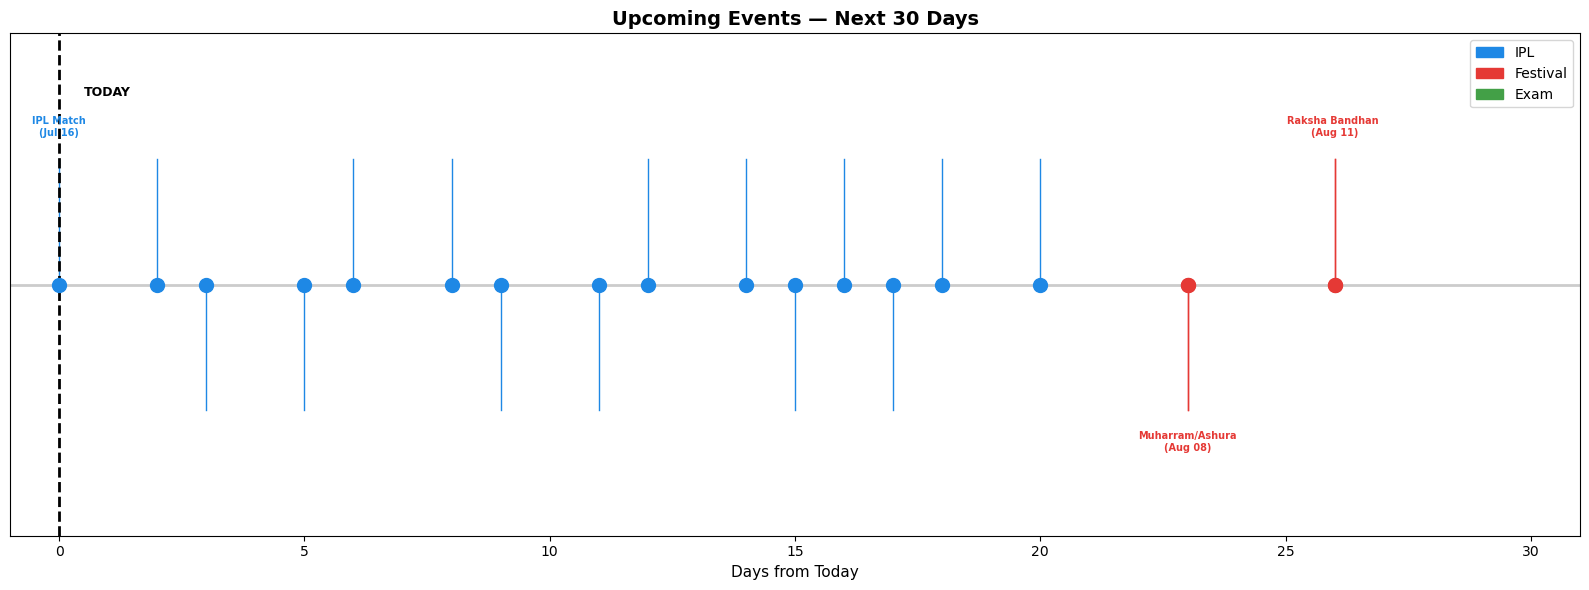

Chart 2 saved


In [12]:
# ══════════════════════════════════════════════════════
# STEP 24 — Chart 2: Event Timeline
# ══════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 6))

# Get next 30 days events
today = pd.Timestamp.today()
next_30 = today + pd.Timedelta(days=30)

upcoming = event_master_final[
    (event_master_final['date'] >= today) &
    (event_master_final['date'] <= next_30)
].copy()

# Color by event type
type_colors = {
    'IPL':      '#1E88E5',
    'Festival': '#E53935',
    'Exam':     '#43A047'
}

# Plot timeline
ax.axhline(y=0, color='#CCCCCC', linewidth=2, zorder=1)

plotted_labels = {}
for _, event in upcoming.iterrows():
    days = (event['date'] - today).days
    color = type_colors.get(event['event_type'], '#999999')
    
    # Alternate above and below to avoid overlap
    y = 0.3 if days % 2 == 0 else -0.3
    
    ax.scatter(days, 0, color=color, s=100, zorder=3)
    ax.plot([days, days], [0, y], color=color, linewidth=1, zorder=2)
    
    # Only label unique event names to avoid clutter
    label = event['festival_name'][:15]
    if label not in plotted_labels:
        ax.text(days, y + (0.05 if y > 0 else -0.05),
                f"{label}\n({event['date'].strftime('%b %d')})",
                ha='center', va='bottom' if y > 0 else 'top',
                fontsize=7, color=color, fontweight='bold')
        plotted_labels[label] = True

# Today marker
ax.axvline(x=0, color='black', linewidth=2, linestyle='--', label='Today')
ax.text(0.5, 0.45, 'TODAY', fontsize=9, fontweight='bold')

# Legend
patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
ax.legend(handles=patches, loc='upper right', fontsize=10)

ax.set_xlim(-1, 31)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel('Days from Today', fontsize=11)
ax.set_title('Upcoming Events — Next 30 Days', fontsize=14, fontweight='bold')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('../outputs/chart2_event_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

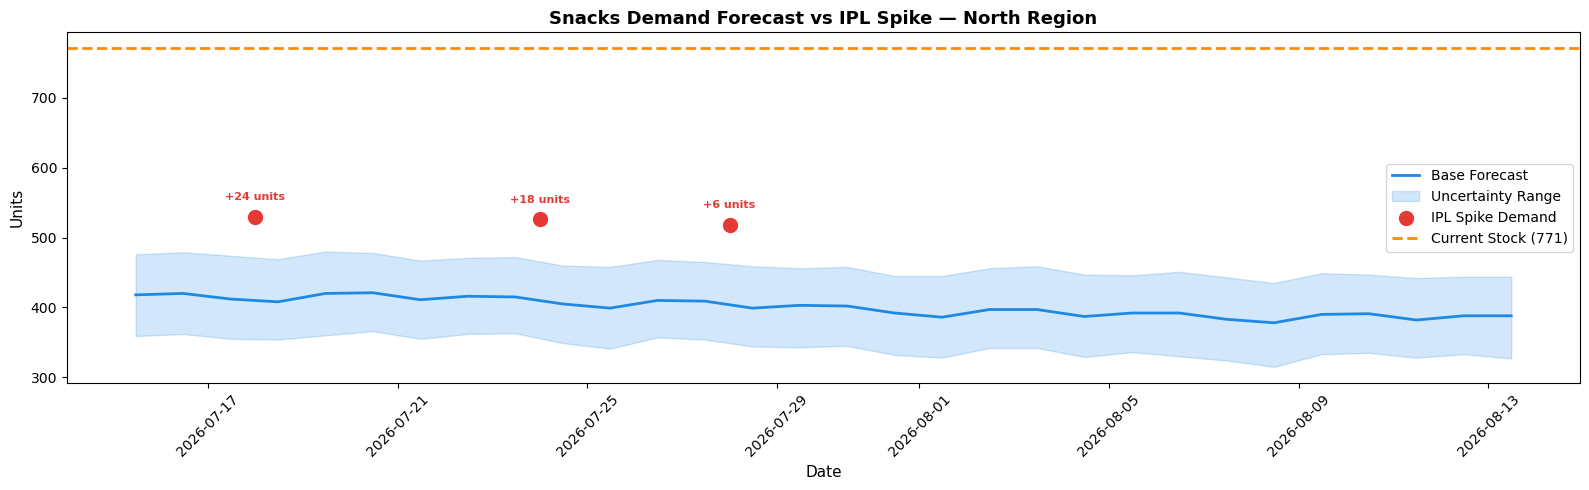

Chart 3 saved


In [13]:
# ══════════════════════════════════════════════════════
# STEP 25 — Chart 3: Forecast vs Predicted Spike
# ══════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 5))

# Get Snacks - North forecast
snacks_north = forecast_df_full[
    (forecast_df_full['category'] == 'Snacks') &
    (forecast_df_full['region'] == 'North')
].copy()

snacks_north = snacks_north.sort_values('date')

# Plot base forecast
ax.plot(snacks_north['date'], snacks_north['forecasted_demand'],
        color='#1E88E5', linewidth=2, label='Base Forecast')

# Plot uncertainty band
ax.fill_between(snacks_north['date'],
                snacks_north['lower_bound'],
                snacks_north['upper_bound'],
                alpha=0.2, color='#1E88E5', label='Uncertainty Range')

# Plot spike demand for IPL match days
ipl_alerts = final_alerts[
    (final_alerts['category'] == 'Snacks') &
    (final_alerts['region'] == 'North') &
    (final_alerts['event_type'] == 'IPL')
].copy()

ipl_alerts['event_date'] = pd.to_datetime(ipl_alerts['event_date'])

ax.scatter(ipl_alerts['event_date'], ipl_alerts['predicted_demand'],
           color='#E53935', s=100, zorder=5, label='IPL Spike Demand')

# Annotate IPL points
for _, row in ipl_alerts.iterrows():
    ax.annotate(f"+{row['order_quantity']} units",
                xy=(row['event_date'], row['predicted_demand']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8, color='#E53935', fontweight='bold')

# Current stock line
ax.axhline(y=771, color='#FF8C00', linewidth=2,
           linestyle='--', label='Current Stock (771)')

ax.set_title('Snacks Demand Forecast vs IPL Spike — North Region',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Units', fontsize=11)
ax.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/chart3_forecast_vs_spike.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

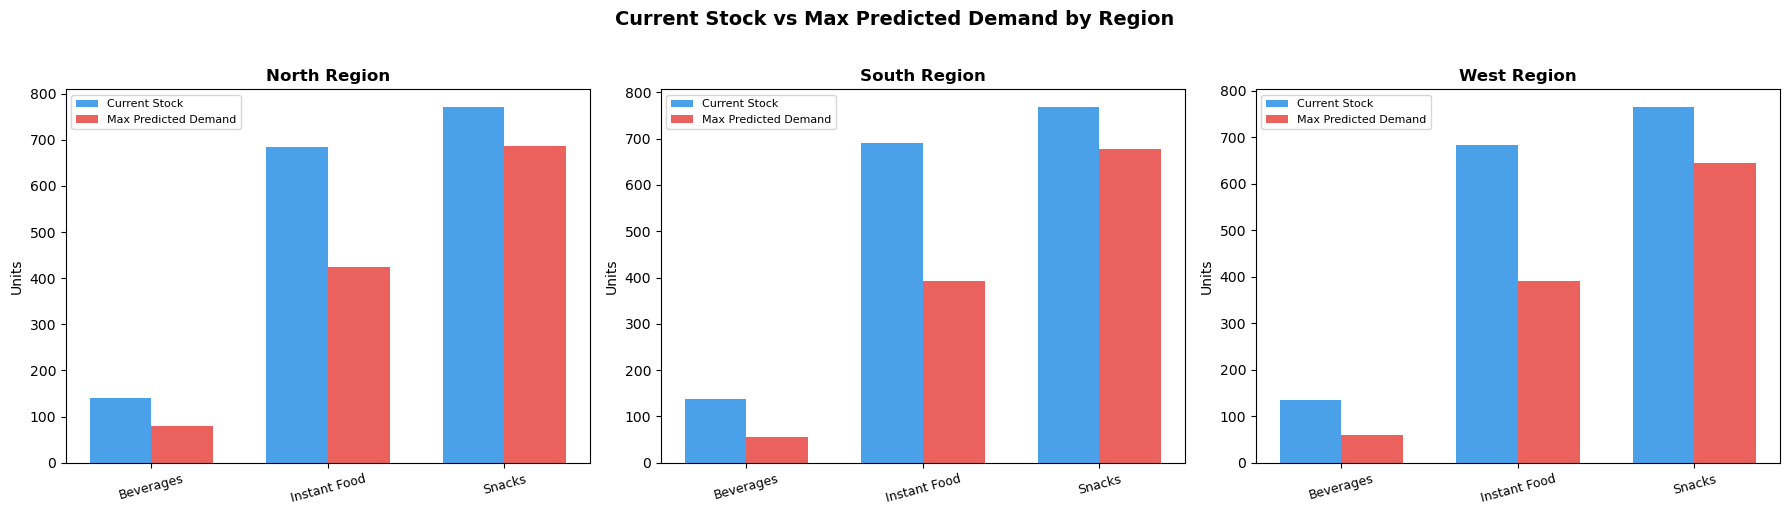

Chart 4 saved


In [14]:
# ══════════════════════════════════════════════════════
# STEP 26 — Chart 4: Stock Gap Bar Chart
# ══════════════════════════════════════════════════════

import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

regions = ['North', 'South', 'West']

for i, region in enumerate(regions):
    ax = axes[i]

    # Get max predicted demand per category for this region
    region_alerts = alerts_df[alerts_df['region'] == region].groupby('category').agg(
        max_predicted=('predicted_demand', 'max'),
        current_stock=('current_stock', 'first')
    ).reset_index()

    if region_alerts.empty:
        continue

    x = np.arange(len(region_alerts))
    width = 0.35

    bars1 = ax.bar(x - width/2, region_alerts['current_stock'],
                   width, label='Current Stock', color='#1E88E5', alpha=0.8)
    bars2 = ax.bar(x + width/2, region_alerts['max_predicted'],
                   width, label='Max Predicted Demand', color='#E53935', alpha=0.8)

    ax.set_title(f'{region} Region', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(region_alerts['category'], rotation=15, fontsize=9)
    ax.set_ylabel('Units', fontsize=10)
    ax.legend(fontsize=8)

    # Annotate gap
    for j, row in region_alerts.iterrows():
        gap = row['max_predicted'] - row['current_stock']
        if gap > 0:
            ax.text(j + width/2, row['max_predicted'] + 5,
                    f'+{int(gap)}', ha='center', fontsize=8,
                    color='#E53935', fontweight='bold')

fig.suptitle('Current Stock vs Max Predicted Demand by Region',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../outputs/chart4_stock_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

In [15]:
# ╔══════════════════════════════════════════════════════╗
# ║         RUN THIS BEFORE EVERY DEMO                  ║
# ║  Updates forecast and alerts to today's date         ║
# ╚══════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print(f"Running demo prep for: {pd.Timestamp.today().date()}")
print("=" * 50)

# ── STEP 1: Load all base data ──────────────────────
print("\n[1/4] Loading data...")

daily_sales_full = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales_full['date'] = pd.to_datetime(daily_sales_full['date'])

event_master_final = pd.read_csv('../data/processed/event_master.csv')
event_master_final['date'] = pd.to_datetime(event_master_final['date'])

inventory_df = pd.read_csv('../data/processed/inventory.csv')

holidays = event_master_final[['date', 'festival_name']].copy()
holidays.columns = ['ds', 'holiday']

print("    ✓ Data loaded successfully")

# ── STEP 2: Re-run Prophet ───────────────────────────
print("\n[2/4] Running Prophet forecast from today...")

forecasts = []
categories = daily_sales_full['category'].unique()
regions = ['North', 'South', 'West']

for category in categories:
    for region in regions:

        df = daily_sales_full[
            (daily_sales_full['category'] == category) &
            (daily_sales_full['region'] == region)
        ][['date', 'units_sold']].copy()

        df.columns = ['ds', 'y']
        df = df.sort_values('ds').reset_index(drop=True)

        if len(df) < 100:
            continue

        model = Prophet(
            holidays=holidays,
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            changepoint_prior_scale=0.05
        )

        model.fit(df)

        today = pd.Timestamp.today()
        future_dates = pd.date_range(start=today, periods=30, freq='D')
        future = pd.DataFrame({'ds': future_dates})
        forecast = model.predict(future)

        forecast_out = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
        forecast_out['category'] = category
        forecast_out['region'] = region
        forecasts.append(forecast_out)

forecast_df_full = pd.concat(forecasts, ignore_index=True)
forecast_df_full.columns = ['date', 'forecasted_demand', 'lower_bound', 'upper_bound', 'category', 'region']
forecast_df_full['forecasted_demand'] = forecast_df_full['forecasted_demand'].round(0).clip(lower=0).astype(int)
forecast_df_full['lower_bound'] = forecast_df_full['lower_bound'].round(0).clip(lower=0).astype(int)
forecast_df_full['upper_bound'] = forecast_df_full['upper_bound'].round(0).clip(lower=0).astype(int)
forecast_df_full.to_csv('../data/processed/forecast.csv', index=False)

print(f"    ✓ Forecast ready: {forecast_df_full['date'].min().date()} to {forecast_df_full['date'].max().date()}")

# ── STEP 3: Re-run Alert Engine ─────────────────────
print("\n[3/4] Generating restock alerts...")

def critical_ratio(selling_price, unit_cost, salvage_value):
    return (selling_price - unit_cost) / (selling_price - salvage_value)

inventory_df['critical_ratio'] = inventory_df.apply(
    lambda r: critical_ratio(r['selling_price'], r['unit_cost'], r['salvage_value']),
    axis=1
)

event_sensitivity = {
    'IPL':      ['Snacks', 'Beverages'],
    'Festival': ['Snacks', 'Beverages', 'Dairy', 'Instant Food'],
    'Exam':     ['Stationery', 'Instant Food'],
}

importance_multiplier = {
    'Very High': 2.5,
    'High':      1.8,
    'Medium':    1.3,
}

alerts = []

for _, event in event_master_final.iterrows():
    event_date = event['date']
    event_type = event['event_type']
    event_region = event['region']
    importance = event['importance']
    event_name = event['festival_name']

    sensitive_cats = event_sensitivity.get(event_type, [])

    for category in sensitive_cats:

        if event_region == 'All':
            alert_regions = ['North', 'South', 'West']
        else:
            alert_regions = [event_region]

        for region in alert_regions:

            fc = forecast_df_full[
                (forecast_df_full['date'].dt.date == event_date.date()) &
                (forecast_df_full['category'] == category) &
                (forecast_df_full['region'] == region)
            ]

            if fc.empty:
                continue

            base_demand = fc['forecasted_demand'].values[0]
            multiplier = importance_multiplier.get(importance, 1.3)
            predicted_demand = int(base_demand * multiplier)

            inv = inventory_df[
                (inventory_df['category'] == category) &
                (inventory_df['region'] == region)
            ]

            if inv.empty:
                continue

            current_stock = inv['current_stock'].values[0]
            max_capacity = inv['max_capacity'].values[0]
            shelf_life = inv['shelf_life_days'].values[0]
            lead_time = inv['lead_time_days'].values[0]
            cr = inv['critical_ratio'].values[0]

            optimal_stock = int(predicted_demand * (1 + cr))
            order_qty = max(0, optimal_stock - current_stock)
            order_qty = min(order_qty, max_capacity - current_stock)
            order_qty = max(0, order_qty)

            days_to_event = (event_date - pd.Timestamp.today()).days
            if days_to_event > shelf_life or days_to_event < 0:
                continue

            order_by_date = event_date - pd.Timedelta(days=lead_time)

            if days_to_event <= 3:
                urgency = 'HIGH'
            elif days_to_event <= 7:
                urgency = 'MEDIUM'
            elif days_to_event <= 14:
                urgency = 'LOW'
            else:
                urgency = 'PLAN AHEAD'

            alerts.append({
                'event_name':        event_name,
                'event_date':        event_date.date(),
                'event_type':        event_type,
                'region':            region,
                'category':          category,
                'base_demand':       base_demand,
                'spike_multiplier':  multiplier,
                'predicted_demand':  predicted_demand,
                'current_stock':     current_stock,
                'order_quantity':    order_qty,
                'order_by_date':     order_by_date.date(),
                'days_to_event':     days_to_event,
                'urgency':           urgency,
            })

alerts_df = pd.DataFrame(alerts)
final_alerts = alerts_df[alerts_df['order_quantity'] > 0].drop_duplicates()

urgency_order = {'HIGH': 1, 'MEDIUM': 2, 'LOW': 3, 'PLAN AHEAD': 4}
final_alerts['urgency_rank'] = final_alerts['urgency'].map(urgency_order)
final_alerts = final_alerts.sort_values(
    ['urgency_rank', 'event_date']
).drop(columns=['urgency_rank']).reset_index(drop=True)

final_alerts.to_csv('../outputs/restock_alerts.csv', index=False)

print(f"    ✓ {len(final_alerts)} restock alerts generated")
print(f"    ✓ Urgency breakdown: {final_alerts['urgency'].value_counts().to_dict()}")

# ── STEP 4: Done ─────────────────────────────────────
print("\n[4/4] All outputs saved")
print("\n" + "=" * 50)
print("DEMO READY")
print(f"Forecast period : {forecast_df_full['date'].min().date()} → {forecast_df_full['date'].max().date()}")
print(f"Total alerts    : {len(final_alerts)}")
print(f"HIGH urgency    : {len(final_alerts[final_alerts['urgency'] == 'HIGH'])}")
print("Refresh Power BI to update dashboard")
print("=" * 50)

11:41:40 - cmdstanpy - INFO - Chain [1] start processing


Running demo prep for: 2026-07-15

[1/4] Loading data...
    ✓ Data loaded successfully

[2/4] Running Prophet forecast from today...


11:41:41 - cmdstanpy - INFO - Chain [1] done processing
11:41:41 - cmdstanpy - INFO - Chain [1] start processing
11:41:41 - cmdstanpy - INFO - Chain [1] done processing
11:41:41 - cmdstanpy - INFO - Chain [1] start processing
11:41:42 - cmdstanpy - INFO - Chain [1] done processing
11:41:42 - cmdstanpy - INFO - Chain [1] start processing
11:41:42 - cmdstanpy - INFO - Chain [1] done processing
11:41:42 - cmdstanpy - INFO - Chain [1] start processing
11:41:42 - cmdstanpy - INFO - Chain [1] done processing
11:41:43 - cmdstanpy - INFO - Chain [1] start processing
11:41:43 - cmdstanpy - INFO - Chain [1] done processing
11:41:43 - cmdstanpy - INFO - Chain [1] start processing
11:41:43 - cmdstanpy - INFO - Chain [1] done processing
11:41:44 - cmdstanpy - INFO - Chain [1] start processing
11:41:44 - cmdstanpy - INFO - Chain [1] done processing
11:41:44 - cmdstanpy - INFO - Chain [1] start processing
11:41:44 - cmdstanpy - INFO - Chain [1] done processing
11:41:44 - cmdstanpy - INFO - Chain [1] 

    ✓ Forecast ready: 2026-07-15 to 2026-08-13

[3/4] Generating restock alerts...
    ✓ 12 restock alerts generated
    ✓ Urgency breakdown: {'PLAN AHEAD': 6, 'LOW': 3, 'HIGH': 2, 'MEDIUM': 1}

[4/4] All outputs saved

DEMO READY
Forecast period : 2026-07-15 → 2026-08-13
Total alerts    : 12
HIGH urgency    : 2
Refresh Power BI to update dashboard
